# SBI Dataset-size Diagnostics

Analyze the cluster SBI sweep outputs as a function of the number of training datapoints. The notebook discovers every `N*` run under `HPC_output/HalfDome/Emulator/Dataset_test`, then plots posterior width normalized by the prior range, normalized posterior variance, pull, and loss summaries versus `n_train`.

In [1]:
from __future__ import annotations

import csv
import json
import math
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PARAM_NAMES = [
    "P0",
    "xc",
    "beta",
    "alpha_m_P0",
    "alpha_m_xc",
    "alpha_m_beta",
    "alpha_z_P0",
    "alpha_z_xc",
    "alpha_z_beta",
]

# Fiducial values used by the existing cluster SBI analysis notebook.
THETA_TRUE = np.array([18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758, 0.731, 0.415], dtype=float)

DEFAULT_PRIOR = {
    "P0": [2.0, 25.0],
    "xc": [0.12, 0.70],
    "beta": [3.8, 5.2],
    "alpha_m_P0": [0.0, 0.30],
    "alpha_m_xc": [-0.08, 0.08],
    "alpha_m_beta": [0.0, 0.08],
    "alpha_z_P0": [-1.10, -0.40],
    "alpha_z_xc": [0.10, 0.90],
    "alpha_z_beta": [0.25, 0.55],
}

PULL_KIND = "mean"  # "mean" or "median"
XSCALE = "log"
SAVE_FIGURES = True
SAVE_TABLES = True
FIGURE_DPI = 160


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "HPC_output").exists() and (candidate / "SBI_analysis").exists():
            return candidate
    fallback = Path("/home/cbllover/HalfDome")
    if fallback.exists():
        return fallback
    return start


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "HPC_output" / "HalfDome" / "Emulator" / "Dataset_test"
if not DATA_ROOT.exists():
    DATA_ROOT = Path(r"\\wsl.localhost\myrootfs\home\cbllover\HalfDome\HPC_output\HalfDome\Emulator\Dataset_test")

CONFIG_PATH = REPO_ROOT / "SBI_analysis" / "configs" / "default_cluster.json"
FIGURE_DIR = DATA_ROOT / "diagnostic_plots"
TABLE_DIR = DATA_ROOT / "diagnostic_tables"

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}")

print(f"Repo root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Config path: {CONFIG_PATH}")

Repo root: /home/cbllover/HalfDome
Data root: /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test
Config path: /home/cbllover/HalfDome/SBI_analysis/configs/default_cluster.json


In [2]:
def read_json(path: Path) -> dict:
    if not path.exists() or path.stat().st_size == 0:
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_prior_bounds(config_path: Path, param_names: list[str]) -> tuple[np.ndarray, np.ndarray]:
    prior = dict(DEFAULT_PRIOR)
    if config_path.exists():
        config = read_json(config_path)
        prior.update(config.get("prior", {}))
    missing = [name for name in param_names if name not in prior]
    if missing:
        raise KeyError(f"Missing prior bounds for: {missing}")
    low = np.array([prior[name][0] for name in param_names], dtype=float)
    high = np.array([prior[name][1] for name in param_names], dtype=float)
    if np.any(high <= low):
        raise ValueError("Every prior upper bound must be greater than the lower bound")
    return low, high


def n_train_from_dir(run_dir: Path, metadata: dict) -> int:
    if "n_train" in metadata:
        return int(metadata["n_train"])
    match = re.fullmatch(r"N(\d+)", run_dir.name)
    if not match:
        raise ValueError(f"Cannot infer n_train from {run_dir}")
    return int(match.group(1))


def discover_runs(data_root: Path) -> list[dict]:
    runs = []
    for run_dir in sorted(data_root.rglob("N*")):
        if not run_dir.is_dir() or not re.fullmatch(r"N\d+", run_dir.name):
            continue
        metadata_path = run_dir / "run_metadata.json"
        metadata = read_json(metadata_path)
        posterior_samples_path = run_dir / "posterior_samples.npy"
        loss_history_path = run_dir / "loss_history.npz"
        if not posterior_samples_path.exists() and not loss_history_path.exists():
            continue
        runs.append({
            "n_train": n_train_from_dir(run_dir, metadata),
            "job_id": run_dir.parent.parent.name if run_dir.parent.parent != data_root else "",
            "group": run_dir.parent.name,
            "run_dir": run_dir,
            "metadata_path": metadata_path,
            "posterior_samples_path": posterior_samples_path,
            "loss_history_path": loss_history_path,
            "metadata": metadata,
            "posterior_available": posterior_samples_path.exists() and posterior_samples_path.stat().st_size > 0,
            "loss_available": loss_history_path.exists() and loss_history_path.stat().st_size > 0,
        })
    if not runs:
        raise FileNotFoundError(f"No N* runs found under {data_root}")
    return sorted(runs, key=lambda row: (row["n_train"], str(row["run_dir"])))


def format_value(value) -> str:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (bool, np.bool_)):
        return "yes" if value else "no"
    try:
        value_float = float(value)
    except (TypeError, ValueError):
        return str(value)
    if not np.isfinite(value_float):
        return "nan"
    if value_float.is_integer():
        return str(int(value_float))
    if abs(value_float) >= 1000 or (0 < abs(value_float) < 1e-3):
        return f"{value_float:.4g}"
    return f"{value_float:.5f}"


def print_rows(rows: list[dict], columns: list[str], max_rows: int | None = None) -> None:
    shown = rows if max_rows is None else rows[:max_rows]
    widths = {col: max(len(col), *(len(format_value(row.get(col, ""))) for row in shown)) for col in columns}
    header = "  ".join(col.ljust(widths[col]) for col in columns)
    print(header)
    print("  ".join("-" * widths[col] for col in columns))
    for row in shown:
        print("  ".join(format_value(row.get(col, "")).ljust(widths[col]) for col in columns))
    if max_rows is not None and len(rows) > max_rows:
        print(f"... {len(rows) - max_rows} more rows")


prior_low, prior_high = load_prior_bounds(CONFIG_PATH, PARAM_NAMES)
prior_range = prior_high - prior_low
runs = discover_runs(DATA_ROOT)

print(f"Discovered {len(runs)} run directories")
print_rows(
    runs,
    ["n_train", "job_id", "group", "posterior_available", "loss_available"],
)

Discovered 10 run directories
n_train  job_id        group   posterior_available  loss_available
-------  ------------  ------  -------------------  --------------
1024     579469.idark  group4  yes                  yes           
2048     579468.idark  group3  yes                  yes           
4096     579469.idark  group4  yes                  yes           
8192     579467.idark  group2  yes                  yes           
16384    579468.idark  group3  yes                  yes           
32768    579469.idark  group4  yes                  yes           
50000    579469.idark  group4  yes                  yes           
70000    579468.idark  group3  yes                  yes           
85000    579467.idark  group2  yes                  yes           
100000   579466.idark  group1  yes                  yes           


In [3]:
def posterior_stats(samples_path: Path) -> dict[str, np.ndarray | tuple[int, ...]]:
    samples = np.load(samples_path, mmap_mode="r")
    if samples.ndim != 2:
        raise ValueError(f"Expected posterior samples with shape (n_samples, n_params), got {samples.shape}")
    if samples.shape[1] != len(PARAM_NAMES):
        raise ValueError(f"Expected {len(PARAM_NAMES)} parameters, got {samples.shape[1]} in {samples_path}")
    return {
        "shape": tuple(samples.shape),
        "mean": np.asarray(np.mean(samples, axis=0), dtype=float),
        "median": np.asarray(np.median(samples, axis=0), dtype=float),
        "std": np.asarray(np.std(samples, axis=0, ddof=1), dtype=float),
        "variance": np.asarray(np.var(samples, axis=0, ddof=1), dtype=float),
        "q16": np.asarray(np.percentile(samples, 16, axis=0), dtype=float),
        "q84": np.asarray(np.percentile(samples, 84, axis=0), dtype=float),
        "q2.5": np.asarray(np.percentile(samples, 2.5, axis=0), dtype=float),
        "q97.5": np.asarray(np.percentile(samples, 97.5, axis=0), dtype=float),
    }


def loss_stats(loss_path: Path) -> dict[str, float | int]:
    out = {
        "epochs_training": np.nan,
        "epochs_validation": np.nan,
        "first_training_loss": np.nan,
        "final_training_loss": np.nan,
        "first_validation_loss": np.nan,
        "final_validation_loss": np.nan,
        "best_validation_loss": np.nan,
        "final_loss_gap": np.nan,
        "training_loss_drop": np.nan,
        "validation_loss_drop": np.nan,
    }
    if not loss_path.exists() or loss_path.stat().st_size == 0:
        return out
    with np.load(loss_path) as loss_file:
        train_logp = np.asarray(loss_file.get("training_log_probs", []), dtype=float)
        val_logp = np.asarray(loss_file.get("validation_log_probs", []), dtype=float)
        best_logp = np.asarray(loss_file.get("best_validation_log_prob", []), dtype=float)

    if train_logp.size:
        out["epochs_training"] = int(train_logp.size)
        out["first_training_loss"] = float(-train_logp[0])
        out["final_training_loss"] = float(-train_logp[-1])
        out["training_loss_drop"] = float(train_logp[-1] - train_logp[0])
    if val_logp.size:
        out["epochs_validation"] = int(val_logp.size)
        out["first_validation_loss"] = float(-val_logp[0])
        out["final_validation_loss"] = float(-val_logp[-1])
        out["validation_loss_drop"] = float(val_logp[-1] - val_logp[0])
        out["best_validation_loss"] = float(-np.nanmax(val_logp))
    if best_logp.size:
        out["best_validation_loss"] = float(-np.nanmax(best_logp))
    if np.isfinite(out["final_validation_loss"]) and np.isfinite(out["final_training_loss"]):
        out["final_loss_gap"] = float(out["final_validation_loss"] - out["final_training_loss"])
    return out


posterior_rows = []
run_rows = []

for run in runs:
    row = {
        "n_train": run["n_train"],
        "job_id": run["job_id"],
        "group": run["group"],
        "run_dir": run["run_dir"],
        "posterior_available": run["posterior_available"],
        "loss_available": run["loss_available"],
    }
    row.update(loss_stats(run["loss_history_path"]))

    if run["posterior_available"]:
        stats = posterior_stats(run["posterior_samples_path"])
        row["posterior_sample_count"] = int(stats["shape"][0])
        for index, name in enumerate(PARAM_NAMES):
            std = float(stats["std"][index])
            variance = float(stats["variance"][index])
            mean = float(stats["mean"][index])
            median = float(stats["median"][index])
            true = float(THETA_TRUE[index])
            posterior_rows.append({
                "n_train": run["n_train"],
                "job_id": run["job_id"],
                "group": run["group"],
                "parameter": name,
                "true": true,
                "prior_low": float(prior_low[index]),
                "prior_high": float(prior_high[index]),
                "prior_range": float(prior_range[index]),
                "mean": mean,
                "median": median,
                "std": std,
                "variance": variance,
                "std_over_prior_range": float(std / prior_range[index]),
                "variance_over_prior_range2": float(variance / (prior_range[index] ** 2)),
                "q16": float(stats["q16"][index]),
                "q84": float(stats["q84"][index]),
                "q2.5": float(stats["q2.5"][index]),
                "q97.5": float(stats["q97.5"][index]),
                "pull_mean": float((mean - true) / std) if std > 0 else np.nan,
                "pull_median": float((median - true) / std) if std > 0 else np.nan,
            })
    else:
        row["posterior_sample_count"] = 0
    run_rows.append(row)

run_rows = sorted(run_rows, key=lambda row: row["n_train"])
posterior_rows = sorted(posterior_rows, key=lambda row: (row["parameter"], row["n_train"]))

print("Run-level summary")
print_rows(
    run_rows,
    ["n_train", "job_id", "group", "posterior_sample_count", "loss_available", "final_validation_loss", "best_validation_loss", "final_loss_gap"],
)

print("\nPosterior summary preview")
print_rows(
    posterior_rows,
    ["n_train", "parameter", "std_over_prior_range", "variance_over_prior_range2", "pull_mean", "pull_median"],
    max_rows=18,
)

Run-level summary
n_train  job_id        group   posterior_sample_count  loss_available  final_validation_loss  best_validation_loss  final_loss_gap
-------  ------------  ------  ----------------------  --------------  ---------------------  --------------------  --------------
1024     579469.idark  group4  100000                  yes             -9.20274               -9.62313              1.43389       
2048     579468.idark  group3  100000                  yes             -9.85060               -11.50387             2.22181       
4096     579469.idark  group4  100000                  yes             -11.78496              -12.03205             0.21477       
8192     579467.idark  group2  100000                  yes             -12.98781              -13.90958             0.67839       
16384    579468.idark  group3  100000                  yes             -13.93381              -14.58432             0.44488       
32768    579469.idark  group4  100000                  yes       

In [4]:
def write_csv_table(path: Path, rows: list[dict], columns: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=columns, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)


run_columns = [
    "n_train", "job_id", "group", "run_dir", "posterior_available", "posterior_sample_count", "loss_available",
    "epochs_training", "epochs_validation", "first_training_loss", "final_training_loss",
    "first_validation_loss", "final_validation_loss", "best_validation_loss", "final_loss_gap",
    "training_loss_drop", "validation_loss_drop",
]
posterior_columns = [
    "n_train", "job_id", "group", "parameter", "true", "prior_low", "prior_high", "prior_range",
    "mean", "median", "std", "variance", "std_over_prior_range", "variance_over_prior_range2",
    "q16", "q84", "q2.5", "q97.5", "pull_mean", "pull_median",
]

if SAVE_TABLES:
    write_csv_table(TABLE_DIR / "run_loss_summary.csv", run_rows, run_columns)
    write_csv_table(TABLE_DIR / "posterior_parameter_summary.csv", posterior_rows, posterior_columns)
    print(f"Saved CSV summaries to {TABLE_DIR}")

Saved CSV summaries to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_tables


In [5]:
def save_figure(fig, filename: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved {path}")


def values_for_parameter(metric: str, parameter: str) -> tuple[np.ndarray, np.ndarray]:
    rows = [row for row in posterior_rows if row["parameter"] == parameter and np.isfinite(row.get(metric, np.nan))]
    rows = sorted(rows, key=lambda row: row["n_train"])
    x = np.array([row["n_train"] for row in rows], dtype=float)
    y = np.array([row[metric] for row in rows], dtype=float)
    return x, y


def plot_metric_facets(metric: str, ylabel: str, title: str, filename: str, hlines: list[float] | None = None):
    ncols = 3
    nrows = math.ceil(len(PARAM_NAMES) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.05 * nrows), sharex=True)
    axes = np.asarray(axes).ravel()
    for ax, parameter in zip(axes, PARAM_NAMES):
        x, y = values_for_parameter(metric, parameter)
        ax.plot(x, y, marker="o", linewidth=1.8, markersize=4.5)
        if hlines:
            for hline in hlines:
                style = "-" if hline == 0 else "--"
                alpha = 0.7 if hline == 0 else 0.35
                ax.axhline(hline, color="black", linestyle=style, linewidth=0.9, alpha=alpha)
        ax.set_title(parameter)
        ax.set_xscale(XSCALE)
        ax.grid(True, which="both", alpha=0.25)
        ax.set_xlabel("number of datapoints")
        ax.set_ylabel(ylabel)
    for ax in axes[len(PARAM_NAMES):]:
        ax.axis("off")
    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()
    save_figure(fig, filename)
    return fig


def plot_metric_overlay(metric: str, ylabel: str, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    for parameter in PARAM_NAMES:
        x, y = values_for_parameter(metric, parameter)
        ax.plot(x, y, marker="o", linewidth=1.7, markersize=4, label=parameter)
    ax.set_xscale(XSCALE)
    ax.set_xlabel("number of datapoints")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(ncol=3, fontsize=8, frameon=False)
    fig.tight_layout()
    save_figure(fig, filename)
    return fig

## Posterior Width and Variance

`std / prior_range` is the most directly interpretable posterior width fraction. `variance / prior_range^2` is the dimensionless normalized variance.

Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/posterior_std_over_prior_range_overlay.png
Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/posterior_std_over_prior_range_facets.png
Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/posterior_variance_over_prior_range2_facets.png


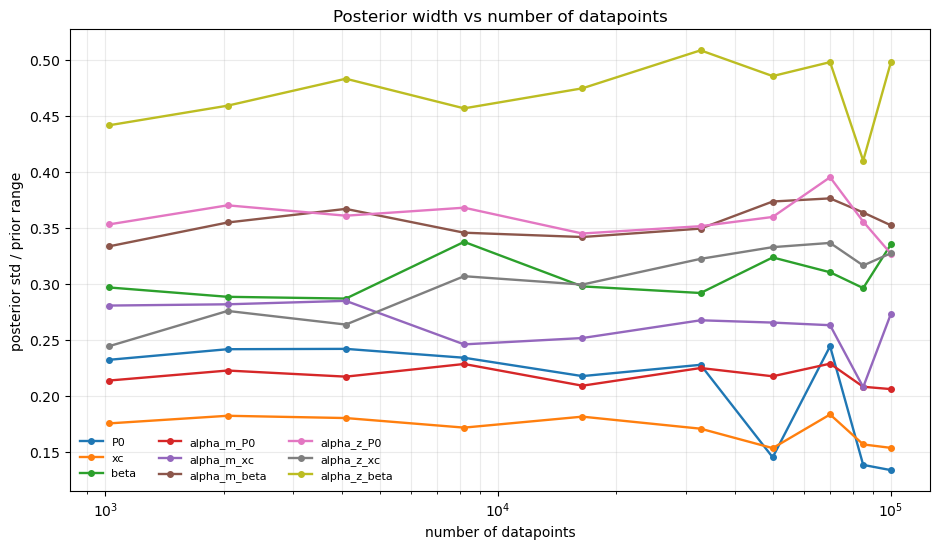

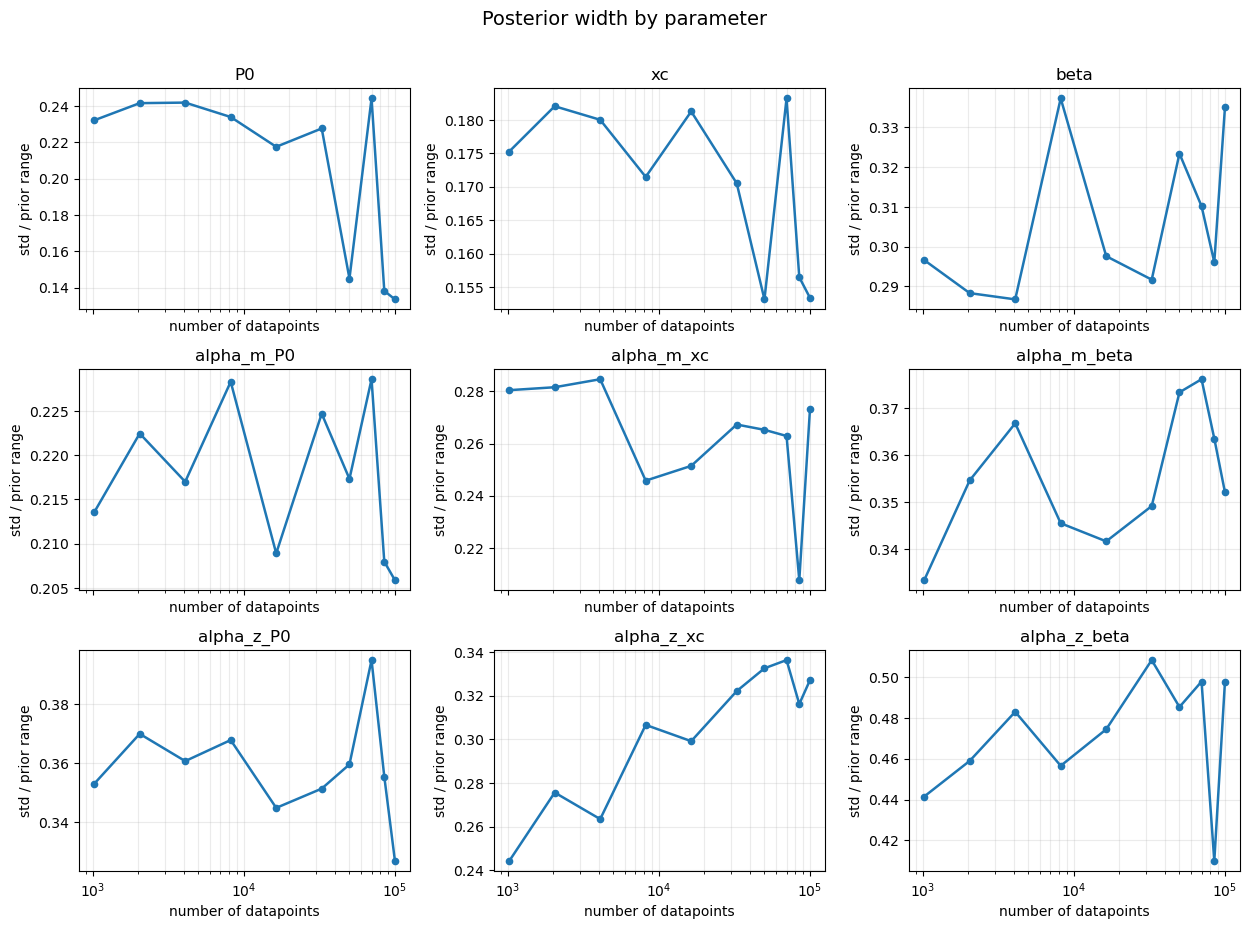

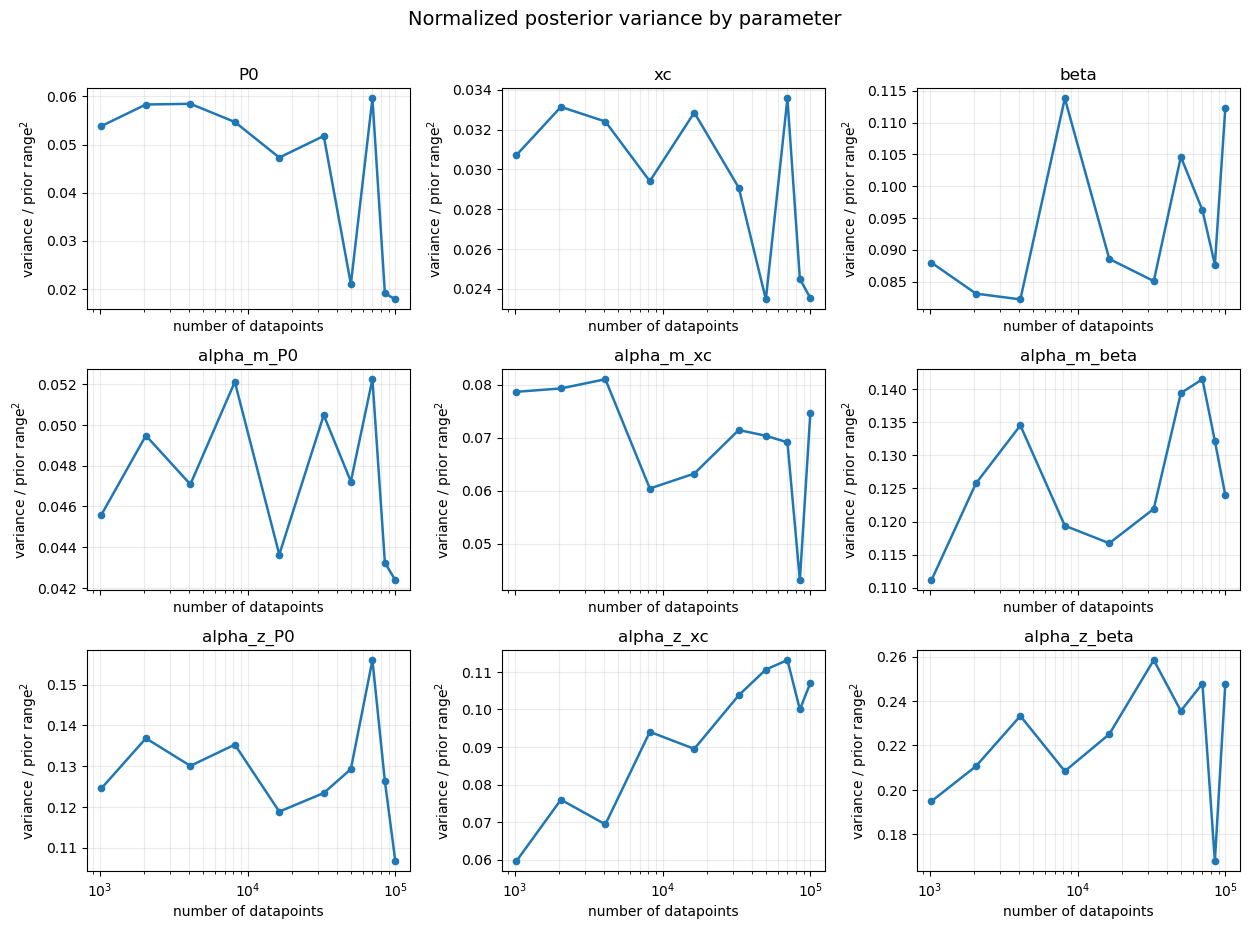

In [6]:
plot_metric_overlay(
    "std_over_prior_range",
    "posterior std / prior range",
    "Posterior width vs number of datapoints",
    "posterior_std_over_prior_range_overlay.png",
);

plot_metric_facets(
    "std_over_prior_range",
    "std / prior range",
    "Posterior width by parameter",
    "posterior_std_over_prior_range_facets.png",
);

plot_metric_facets(
    "variance_over_prior_range2",
    "variance / prior range$^2$",
    "Normalized posterior variance by parameter",
    "posterior_variance_over_prior_range2_facets.png",
);

## Pull

The pull is `(posterior center - true value) / posterior std`. Use `PULL_KIND = "mean"` or `"median"` in the configuration cell to choose the posterior center.

Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/posterior_mean_pull_facets.png


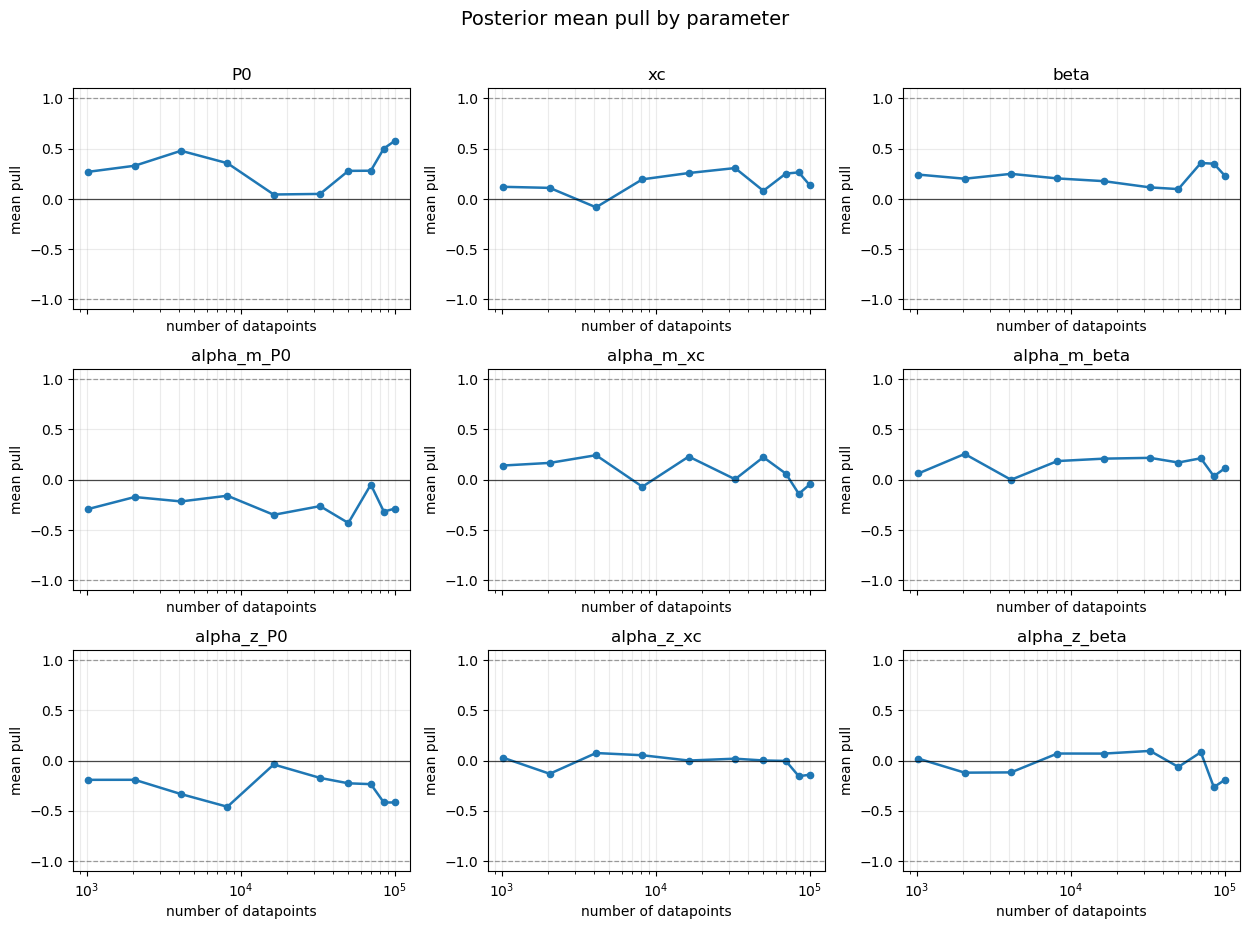

In [7]:
if PULL_KIND not in {"mean", "median"}:
    raise ValueError('PULL_KIND must be "mean" or "median"')

pull_metric = f"pull_{PULL_KIND}"
plot_metric_facets(
    pull_metric,
    f"{PULL_KIND} pull",
    f"Posterior {PULL_KIND} pull by parameter",
    f"posterior_{PULL_KIND}_pull_facets.png",
    hlines=[-1, 0, 1],
);

## Loss Variation

The training artifacts store log probabilities. The plots below use loss = `-log_prob`, so lower is better. Runs without `loss_history.npz` are skipped in the loss plots but remain in posterior plots.

Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/loss_summary_vs_n_train.png
Saved /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/diagnostic_plots/loss_gap_and_drop_vs_n_train.png


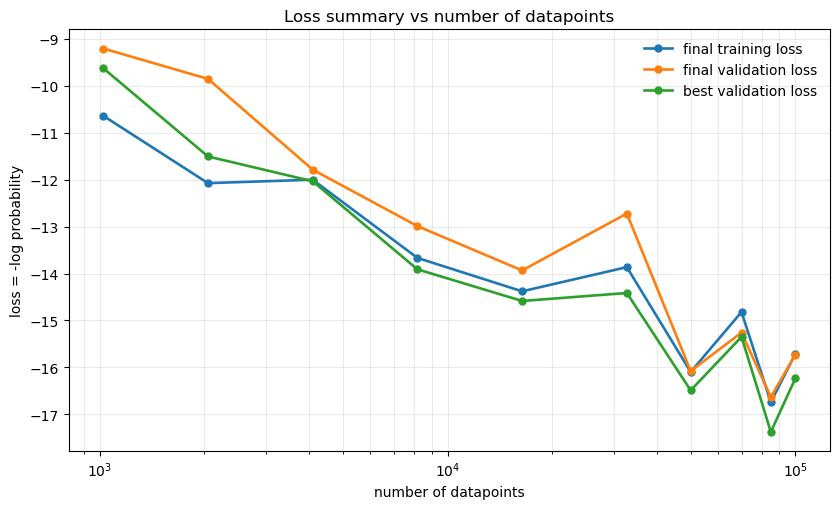

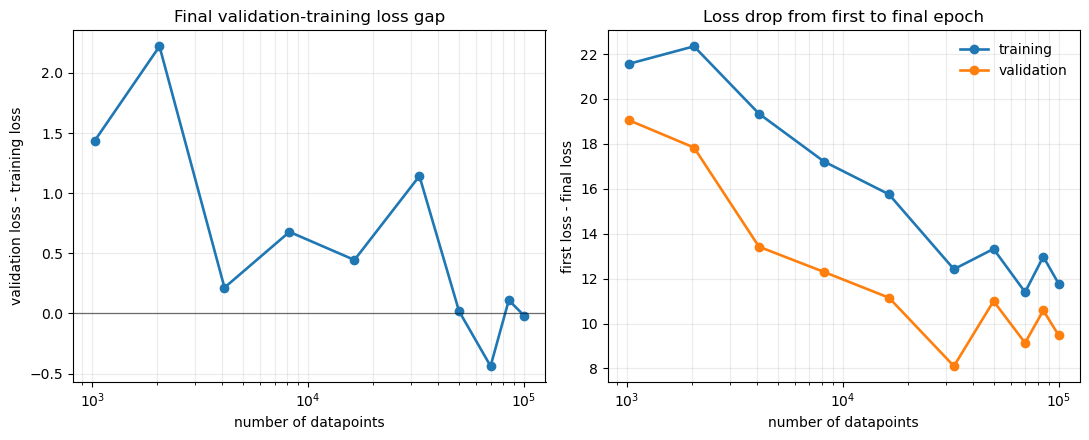

In [8]:
def finite_loss_rows() -> list[dict]:
    rows = [row for row in run_rows if row["loss_available"] and np.isfinite(row["final_validation_loss"])]
    return sorted(rows, key=lambda row: row["n_train"])


def plot_loss_summary():
    rows = finite_loss_rows()
    if not rows:
        print("No loss histories found.")
        return None
    x = np.array([row["n_train"] for row in rows], dtype=float)
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for key, label in [
        ("final_training_loss", "final training loss"),
        ("final_validation_loss", "final validation loss"),
        ("best_validation_loss", "best validation loss"),
    ]:
        y = np.array([row[key] for row in rows], dtype=float)
        ax.plot(x, y, marker="o", linewidth=1.9, markersize=5, label=label)
    ax.set_xscale(XSCALE)
    ax.set_xlabel("number of datapoints")
    ax.set_ylabel("loss = -log probability")
    ax.set_title("Loss summary vs number of datapoints")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "loss_summary_vs_n_train.png")
    return fig


def plot_loss_gap_and_drop():
    rows = finite_loss_rows()
    if not rows:
        return None
    x = np.array([row["n_train"] for row in rows], dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(x, [row["final_loss_gap"] for row in rows], marker="o", linewidth=1.9)
    axes[0].axhline(0, color="black", linewidth=0.9, alpha=0.55)
    axes[0].set_title("Final validation-training loss gap")
    axes[0].set_ylabel("validation loss - training loss")

    axes[1].plot(x, [row["training_loss_drop"] for row in rows], marker="o", linewidth=1.9, label="training")
    axes[1].plot(x, [row["validation_loss_drop"] for row in rows], marker="o", linewidth=1.9, label="validation")
    axes[1].set_title("Loss drop from first to final epoch")
    axes[1].set_ylabel("first loss - final loss")
    axes[1].legend(frameon=False)

    for ax in axes:
        ax.set_xscale(XSCALE)
        ax.set_xlabel("number of datapoints")
        ax.grid(True, which="both", alpha=0.25)
    fig.tight_layout()
    save_figure(fig, "loss_gap_and_drop_vs_n_train.png")
    return fig


plot_loss_summary();
plot_loss_gap_and_drop();

## Numerical Tables

The full numeric summaries are saved as CSV files when `SAVE_TABLES = True`.

In [9]:
print("Posterior metrics sorted by datapoints and parameter")
print_rows(
    sorted(posterior_rows, key=lambda row: (row["n_train"], PARAM_NAMES.index(row["parameter"]))),
    ["n_train", "parameter", "mean", "std", "std_over_prior_range", "variance_over_prior_range2", pull_metric],
)

print("\nLoss metrics sorted by datapoints")
print_rows(
    run_rows,
    ["n_train", "loss_available", "final_training_loss", "final_validation_loss", "best_validation_loss", "final_loss_gap"],
)

Posterior metrics sorted by datapoints and parameter
n_train  parameter     mean       std      std_over_prior_range  variance_over_prior_range2  pull_mean 
-------  ------------  ---------  -------  --------------------  --------------------------  ----------
1024     P0            19.53834   5.33709  0.23205               0.05385                     0.26950   
1024     xc            0.50920    0.10165  0.17527               0.03072                     0.12006   
1024     beta          4.45033    0.41523  0.29660               0.08797                     0.24163   
1024     alpha_m_P0    0.13535    0.06406  0.21354               0.04560                     -0.29107  
1024     alpha_m_xc    -0.00230   0.04487  0.28046               0.07866                     0.14148   
1024     alpha_m_beta  0.04096    0.02667  0.33338               0.11115                     0.06240   
1024     alpha_z_P0    -0.80536   0.24708  0.35297               0.12459                     -0.19167  
1024     al

## Resample Saved NN Posteriors at a Fixed Observation

Use this section to test whether the trained density estimators give stable posteriors when sampled again at the same `x_o`. It loads each selected run's saved `posterior.pkl`, samples from `p(theta | x_o)`, summarizes the posterior mean/pull, and optionally makes GetDist triangle plots for selected dataset sizes.

In [12]:
ell = np.array([
    198.01805, 388.2717, 585.247, 783.7734, 982.90125,
    1182.3248, 1381.9154, 1581.6096, 1781.3726, 1981.1835,
    2181.029, 2380.9006, 2580.792, 2780.699, 2980.6187,
    3180.548, 3380.486, 3580.4312, 3780.3818, 3980.3374,
    4180.2974, 4380.261, 4580.228, 4780.1973, 4980.1694,
    5180.1436, 5380.1196, 5580.097, 5780.0767, 5980.0576,
    6180.0396, 6380.0225, 6580.0063, 6779.9917, 6979.9775,
    7179.9644, 7379.9517, 7579.94, 7779.928, 7929.605,
], dtype=np.float32)

In [33]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor

obs_log10_dl_beamed = apply_gaussian_beam_to_log10_dl(x_o, ell, 1.6)

In [38]:
import os
os.getcwd()

'/home/cbllover/HalfDome/SBI_analysis'

In [40]:
import numpy as np
import healpy as hp
from pathlib import Path

# -----------------------------
# Inputs
# -----------------------------
SO_MAP_PATH = Path("../tSZ_visuals/outputs/so_noise_fullsky/halfdome_fullsky_clean_signal_map_m200c_nside4096_base_cosmo_fid_nobeam_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax8000.fits")
MASK_PATH = None  # or Path("path/to/mask.fits")

EMULATOR_BINNING_PATH = Path(
    "../emulator_tSZ/outputs/binned_40/binned_training_dataset.npz"
)

OUT_PATH = Path("../emulator_tSZ/outputs/binned_40/x_obs_SO_beamed_1p6arcmin_log10_dl.npy")

FWHM_ARCMIN = 1.6
TARGET_FLOOR = 1.0e-40

# -----------------------------
# Load emulator ell grid
# -----------------------------
with np.load(EMULATOR_BINNING_PATH) as d:
    ell_unbinned = d["ell_unbinned"].astype(int)  # 80..7979
    ell_binned_expected = d["ell"].astype(float)

# Emulator used 40 bins:
# 80..279, 280..479, ..., 7680..7879, 7880..7979
bin_members = []
for ell_start in range(80, 7880, 200):
    ell_stop = ell_start + 199
    idx = np.flatnonzero((ell_unbinned >= ell_start) & (ell_unbinned <= ell_stop))
    bin_members.append(idx)

idx = np.flatnonzero((ell_unbinned >= 7880) & (ell_unbinned <= 7979))
bin_members.append(idx)

def bin_2ell_plus_1(values, ell_values, members):
    out = []
    for idx in members:
        ell_bin = ell_values[idx].astype(float)
        weights = 2.0 * ell_bin + 1.0
        out.append(np.average(values[idx], weights=weights))
    return np.asarray(out, dtype=np.float32)

# Sanity check: recovered bin centers should match emulator centers.
ell_binned = bin_2ell_plus_1(ell_unbinned.astype(float), ell_unbinned, bin_members)
print(np.max(np.abs(ell_binned - ell_binned_expected)))

# -----------------------------
# Load SO map and apply beam at map level
# -----------------------------
so_map = hp.read_map(SO_MAP_PATH, field=0, dtype=np.float64, verbose=False)
nside = hp.get_nside(so_map)
lmax = int(ell_unbinned.max())

# so_map = hp.remove_dipole(so_map, fitval=False)

fwhm_rad = np.deg2rad(FWHM_ARCMIN / 60.0)

so_map_beamed = hp.smoothing(
    so_map,
    fwhm=fwhm_rad,
    lmax=lmax,
    pol=False,
)

# Optional mask after beam smoothing.
if MASK_PATH is not None:
    mask = hp.read_map(MASK_PATH, field=0, dtype=np.float64, verbose=False)
    fsky = np.mean(mask**2)
    map_for_cl = so_map_beamed * mask
else:
    fsky = 1.0
    map_for_cl = so_map_beamed

# -----------------------------
# C_ell -> log10(D_ell), then bin
# -----------------------------
cl = hp.anafast(map_for_cl, lmax=lmax) / fsky

ell_full = np.arange(cl.size)
cl_unbinned = cl[ell_unbinned]

dl_unbinned = ell_unbinned * (ell_unbinned + 1.0) * cl_unbinned / (2.0 * np.pi)
log10_dl_unbinned = np.log10(np.maximum(dl_unbinned, TARGET_FLOOR))

x_obs_so_binned = bin_2ell_plus_1(
    log10_dl_unbinned,
    ell_unbinned,
    bin_members,
)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
np.save(OUT_PATH, x_obs_so_binned)

print("Saved:", OUT_PATH)
print("shape:", x_obs_so_binned.shape)
print("ell bins:", ell_binned)

0.0


/tmp/ipykernel_39717/3863915239.py:53: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  so_map = hp.read_map(SO_MAP_PATH, field=0, dtype=np.float64, verbose=False)


Saved: ../emulator_tSZ/outputs/binned_40/x_obs_SO_beamed_1p6arcmin_log10_dl.npy
shape: (40,)
ell bins: [ 198.01805  388.2717   585.247    783.7734   982.90125 1182.3248
 1381.9154  1581.6096  1781.3726  1981.1835  2181.029   2380.9006
 2580.792   2780.699   2980.6187  3180.548   3380.486   3580.4312
 3780.3818  3980.3374  4180.2974  4380.261   4580.228   4780.1973
 4980.1694  5180.1436  5380.1196  5580.097   5780.0767  5980.0576
 6180.0396  6380.0225  6580.0063  6779.9917  6979.9775  7179.9644
 7379.9517  7579.94    7779.928   7929.605  ]


In [43]:
ell_binned

array([ 198.01805,  388.2717 ,  585.247  ,  783.7734 ,  982.90125,
       1182.3248 , 1381.9154 , 1581.6096 , 1781.3726 , 1981.1835 ,
       2181.029  , 2380.9006 , 2580.792  , 2780.699  , 2980.6187 ,
       3180.548  , 3380.486  , 3580.4312 , 3780.3818 , 3980.3374 ,
       4180.2974 , 4380.261  , 4580.228  , 4780.1973 , 4980.1694 ,
       5180.1436 , 5380.1196 , 5580.097  , 5780.0767 , 5980.0576 ,
       6180.0396 , 6380.0225 , 6580.0063 , 6779.9917 , 6979.9775 ,
       7179.9644 , 7379.9517 , 7579.94   , 7779.928  , 7929.605  ],
      dtype=float32)

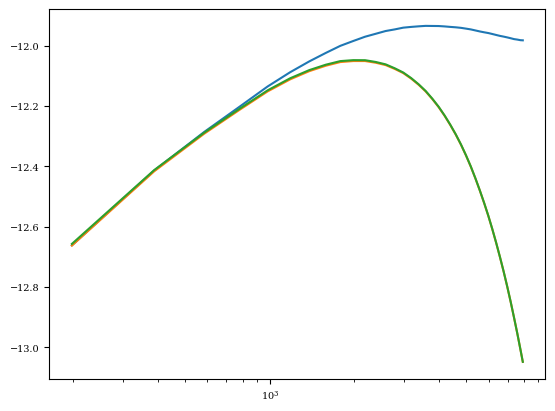

In [41]:
x_o = load_x_o(X_O_SOURCE, key=X_O_KEY)

plt.plot(ell, x_o)
plt.plot(ell, obs_log10_dl_beamed)
plt.plot(ell_binned, x_obs_so_binned)
plt.xscale("log")

Loaded x_o from /home/cbllover/HalfDome/emulator_tSZ/outputs/binned_40/x_obs_log10_dl.npy
x_o shape: (40,), finite=True
Sampling N=1024, group4, 579469.idark from /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/579469.idark/group4/N1024/posterior.pkl


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

  saved (100000, 9) samples to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors/resampled_x_obs_log10_dl_N1024.npy
Sampling N=4096, group4, 579469.idark from /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/579469.idark/group4/N4096/posterior.pkl


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

  saved (100000, 9) samples to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors/resampled_x_obs_log10_dl_N4096.npy
Sampling N=8192, group2, 579467.idark from /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/579467.idark/group2/N8192/posterior.pkl


...

  saved (100000, 9) samples to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors/resampled_x_obs_log10_dl_N50000.npy
Sampling N=85000, group2, 579467.idark from /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/579467.idark/group2/N85000/posterior.pkl


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

  saved (100000, 9) samples to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors/resampled_x_obs_log10_dl_N85000.npy
Sampling N=100000, group1, 579466.idark from /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/579466.idark/group1/N100000/posterior.pkl


Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

  saved (100000, 9) samples to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors/resampled_x_obs_log10_dl_N100000.npy
Saved resampled summaries to /home/cbllover/HalfDome/HPC_output/HalfDome/Emulator/Dataset_test/resampled_posteriors
n_train  parameter     mean      true      mean_minus_true  std      pull_mean
-------  ------------  --------  --------  ---------------  -------  ---------
1024     P0            19.54186  18.10000  1.44186          5.33261  0.27039  
1024     xc            0.51074   0.49700   0.01374          0.10197  0.13476  
1024     beta          4.45273   4.35000   0.10273          0.41520  0.24742  
1024     alpha_m_P0    0.13582   0.15400   -0.01818         0.06414  -0.28342 
1024     alpha_m_xc    -0.00223  -0.00865  0.00642          0.04486  0.14309  
1024     alpha_m_beta  0.04106   0.03930   0.00176          0.02668  0.06587  
1024     alpha_z_P0    -0.80928  -0.75800  -0.05128         0.24731  -0.20734 
1024     alpha_z_x

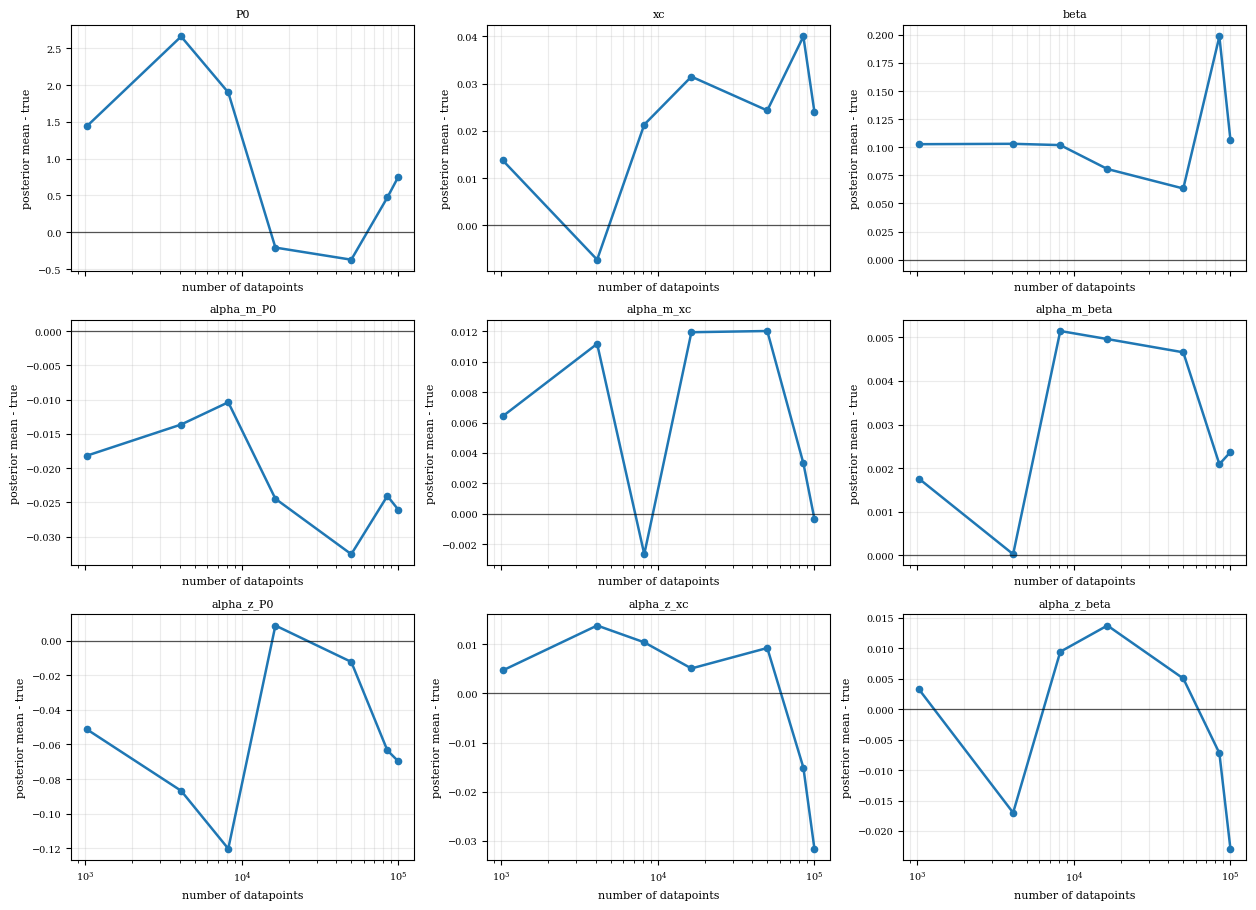

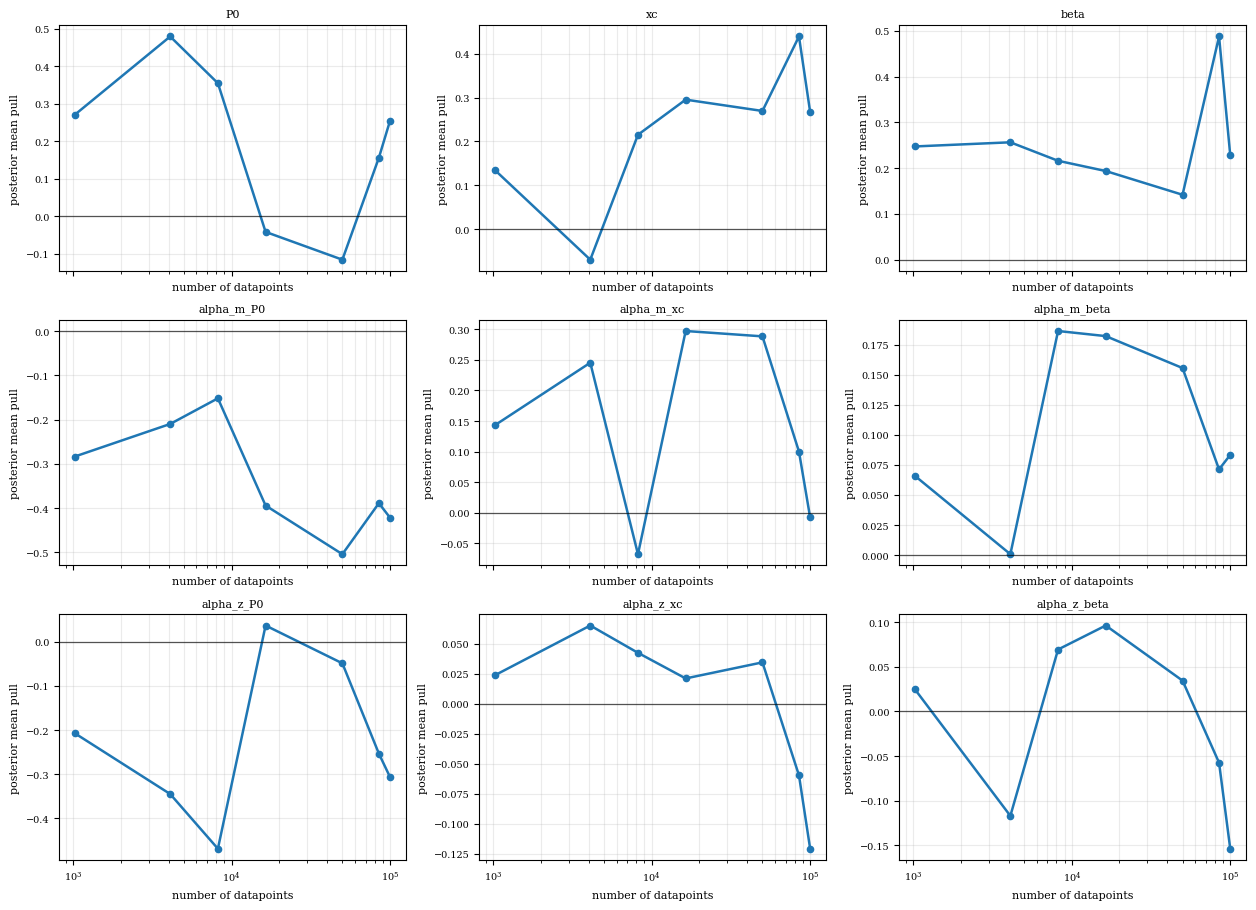

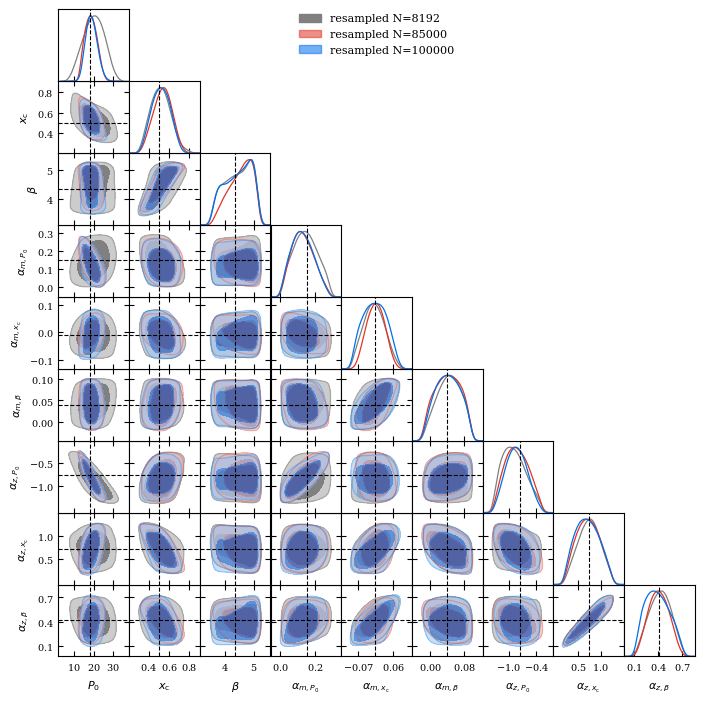

In [42]:
import sys

sys.path.insert(0, str(REPO_ROOT / "SBI_analysis"))

from sbi_resampling_diagnostics import (
    DEFAULT_LATEX_LABELS,
    load_existing_or_resampled_samples,
    load_x_o,
    plot_getdist_triangle,
    plot_resampled_mean_offsets,
    resolve_run_by_n,
    run_label,
    safe_label,
    sample_saved_nn_posterior,
    summarize_posterior_samples,
    write_csv,
)

# Edit these knobs for the resampling test.
X_O_SOURCE = REPO_ROOT / "emulator_tSZ" / "outputs" / "binned_40" / "x_obs_log10_dl.npy"
if not Path(X_O_SOURCE).exists():
    X_O_SOURCE = REPO_ROOT / "SBI_analysis" / "data_for_cluster" / "_sbi_run.npz"
X_O_KEY = None  # For .npz files, leave None to auto-detect obs/x_o/x_obs, or set the key explicitly.

RUN_RESAMPLING = True
RESAMPLE_SELECTED_N = [1024, 4096, 8192, 16384, 50000, 85000, 100000]
RESAMPLE_NUM_POSTERIOR_SAMPLES = 100000
RESAMPLE_DEVICE = "cpu"
RESAMPLE_SEED = 12345

# GetDist can use the freshly resampled arrays, or fall back to existing posterior_samples.npy.
MAKE_GETDIST_TRIANGLE = True
GETDIST_SELECTED_N = [8192, 85000, 100000]
GETDIST_USE_RESAMPLED_SAMPLES = True
GETDIST_OUTPUT = FIGURE_DIR / "getdist_constraints_resampled_selected_N.png"

# x_o = load_x_o(X_O_SOURCE, key=X_O_KEY)
x_o = x_obs_so_binned
x_o_label = safe_label(Path(X_O_SOURCE).stem)
print(f"Loaded x_o from {X_O_SOURCE}")
print(f"x_o shape: {x_o.shape}, finite={np.all(np.isfinite(x_o))}")

resampled_output_dir = DATA_ROOT / "resampled_posteriors"
resampled_samples_by_n = {}
resampled_mean_rows = []

if RUN_RESAMPLING:
    for n_train in RESAMPLE_SELECTED_N:
        run = resolve_run_by_n(runs, int(n_train))
        print(f"Sampling {run_label(run)} from {Path(run['run_dir']) / 'posterior.pkl'}")
        try:
            samples_np, save_path = sample_saved_nn_posterior(
                run,
                x_o,
                num_samples=RESAMPLE_NUM_POSTERIOR_SAMPLES,
                device=RESAMPLE_DEVICE,
                seed=RESAMPLE_SEED,
                output_dir=resampled_output_dir,
                output_label=x_o_label,
            )
        except ModuleNotFoundError as exc:
            raise ModuleNotFoundError(
                "Resampling saved posterior.pkl requires the same torch/sbi environment used for training. "
                "Activate that environment, then rerun this cell."
            ) from exc

        resampled_samples_by_n[int(n_train)] = samples_np
        resampled_mean_rows.extend(
            summarize_posterior_samples(
                samples_np,
                n_train=int(n_train),
                param_names=PARAM_NAMES,
                theta_true=THETA_TRUE,
                label=run_label(run),
            )
        )
        print(f"  saved {samples_np.shape} samples to {save_path}")

    write_csv(resampled_output_dir / f"resampled_mean_summary_{x_o_label}.csv", resampled_mean_rows)
    print(f"Saved resampled summaries to {resampled_output_dir}")

if resampled_mean_rows:
    print_rows(
        resampled_mean_rows,
        ["n_train", "parameter", "mean", "true", "mean_minus_true", "std", "pull_mean"],
        max_rows=36,
    )
    plot_resampled_mean_offsets(
        resampled_mean_rows,
        PARAM_NAMES,
        metric="mean_minus_true",
        ylabel="posterior mean - true",
        xscale=XSCALE,
        output_path=FIGURE_DIR / "resampled_mean_minus_true_vs_n.png",
    )
    plot_resampled_mean_offsets(
        resampled_mean_rows,
        PARAM_NAMES,
        metric="pull_mean",
        ylabel="posterior mean pull",
        xscale=XSCALE,
        output_path=FIGURE_DIR / "resampled_mean_pull_vs_n.png",
    )

if MAKE_GETDIST_TRIANGLE:
    samples_by_label = {}
    for n_train in GETDIST_SELECTED_N:
        samples_np, source_label = load_existing_or_resampled_samples(
            int(n_train),
            runs,
            resampled_samples_by_n,
            prefer_resampled=GETDIST_USE_RESAMPLED_SAMPLES,
        )
        samples_by_label[source_label] = np.asarray(samples_np)

    try:
        plot_getdist_triangle(
            samples_by_label,
            theta_true=THETA_TRUE,
            labels=DEFAULT_LATEX_LABELS,
            output_path=GETDIST_OUTPUT,
        )
    except ModuleNotFoundError as exc:
        print("GetDist is not installed in this kernel. Install it with `pip install getdist` and rerun this cell.")
        print(f"Original import error: {exc!r}")


In [11]:
x_o

array([-12.662442 , -12.414248 , -12.285947 , -12.20135  , -12.135207 ,
       -12.087823 , -12.052037 , -12.023957 , -12.0004425, -11.984304 ,
       -11.970193 , -11.960385 , -11.951286 , -11.945912 , -11.9401655,
       -11.93766  , -11.93574  , -11.934236 , -11.934523 , -11.934748 ,
       -11.936024 , -11.937638 , -11.938992 , -11.940765 , -11.943337 ,
       -11.945931 , -11.949391 , -11.952734 , -11.955544 , -11.958023 ,
       -11.961208 , -11.964453 , -11.967485 , -11.96987  , -11.972476 ,
       -11.97522  , -11.9781275, -11.979711 , -11.9817295, -11.982179 ],
      dtype=float32)